### 完全照抄原仓库renderer的变换逻辑

In [ ]:
import h5py
import numpy as np
import k3d
import trimesh
import os
from omegaconf import OmegaConf

import sys

pkg_root = os.path.abspath("airexo")
if pkg_root not in sys.path:
    sys.path.insert(0, pkg_root)
# 如果之前在同一 kernel 里执行过 `from airexo.airexo...`，
# 需要清理缓存，避免命名空间包 `airexo` 残留。
for _m in [m for m in list(sys.modules.keys()) if m == "airexo" or m.startswith("airexo.")]:
    del sys.modules[_m]

from airexo.helpers.urdf_robot import forward_kinematic
from airexo.helpers.constants import ROBOT_PREDEFINED_TRANSFORMATION, O3D_RENDER_TRANSFORMATION
from airexo.calibration.calib_info import CalibrationInfo
import open3d as o3d

# ========== 1. 读取关节数据 ==========
scene_path = "/data/haoxiang/data/airexo2/task_0013/train/scene_0001"
lowdim_path = os.path.join(scene_path, "lowdim")

with h5py.File(f"{lowdim_path}/robot_left.h5", 'r') as f:
    left_joint = f['joint_pos'][0]
with h5py.File(f"{lowdim_path}/robot_right.h5", 'r') as f:
    right_joint = f['joint_pos'][0]
with h5py.File(f"{lowdim_path}/gripper_left.h5", 'r') as f:
    left_gripper = f['width'][0] if 'width' in f else 0.05
with h5py.File(f"{lowdim_path}/gripper_right.h5", 'r') as f:
    right_gripper = f['width'][0] if 'width' in f else 0.05

left_joint = np.concatenate([left_joint, [left_gripper]])
right_joint = np.concatenate([right_joint, [right_gripper]])

# scene_path = "/data/haoxiang/data/task0012_260321/task0012_toys_basket_converted/scene_0001"
# H5_PATH = os.path.join(scene_path, "lowdim", "lowdim.h5")

# with h5py.File(H5_PATH, "r") as f:
#     # 这里按你之前已经确认的左右映射：
#     # left  <- *_062703
#     # right <- *_062046
#     left_joint_core = np.asarray(f["joint_position_rad_062703"][0], dtype=np.float32)
#     right_joint_core = np.asarray(f["joint_position_rad_062046"][0], dtype=np.float32)

#     # gripper 宽度暂时只能从 ee_state / ee_command 取一个标量占位；
#     # 如果你的 renderer 只需要一个 0~0.085 左右的宽度值，这里先直接取 ee_state。
#     left_gripper = float(np.asarray(f["ee_state_062703"][0]).reshape(-1)[0])
#     right_gripper = float(np.asarray(f["ee_state_062046"][0]).reshape(-1)[0])

# left_joint = np.concatenate([left_joint_core, [left_gripper]], axis=0)
# right_joint = np.concatenate([right_joint_core, [right_gripper]], axis=0)

# print("H5_PATH:", H5_PATH)
# print("left_joint:", left_joint.shape, left_joint)
# print("right_joint:", right_joint.shape, right_joint)

# ========== 2. 加载标定数据 ==========
calib_path = "/data/haoxiang/data/airexo2/task_0013/calib"
calib_info = CalibrationInfo(calib_path=calib_path, calib_timestamp=1737548651048)

camera_serial = list(calib_info.camera_serials_global)[0]
print(f"Using camera: {camera_serial}")

cam_to_base = calib_info.get_camera_to_base(camera_serial)
intrinsic = calib_info.get_intrinsic(camera_serial)

# ========== 3. 前向运动学 ==========
left_cfg = OmegaConf.load("airexo/airexo/configs/joint/left/robot.yaml")
right_cfg = OmegaConf.load("airexo/airexo/configs/joint/right/robot.yaml")

cur_transforms, visuals_map = forward_kinematic(
    left_joint=left_joint, right_joint=right_joint,
    left_joint_cfgs=left_cfg, right_joint_cfgs=right_cfg,
    is_rad=True,
    urdf_file="airexo/airexo/urdf_models/robot/robot_inhand.urdf",
    with_visuals_map=True
)

# ========== 4. 读取深度图并转换为点云 ==========
cam_path = os.path.join(scene_path, f"cam_{camera_serial}")
depth_path = os.path.join(cam_path, "depth", "1737546126606.png")
rgb_path = os.path.join(cam_path, "color", "1737546126606.png")

depth_img = o3d.io.read_image(depth_path)
rgb_img = o3d.io.read_image(rgb_path)
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_img, depth_img, depth_scale=1000.0, convert_rgb_to_intensity=False
)

fx, fy = intrinsic[0,0], intrinsic[1,1]
cx, cy = intrinsic[0,2], intrinsic[1,2]
h, w = np.asarray(rgb_img).shape[:2]
intrinsic_o3d = o3d.camera.PinholeCameraIntrinsic(int(w), int(h), float(fx), float(fy), float(cx), float(cy))

pcd_cam = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic_o3d)
pcd_cam.transform(O3D_RENDER_TRANSFORMATION)

# ========== 5. K3D 可视化 ==========
plot = k3d.plot()

# 变换链：mesh → link → URDF基座 --[ROBOT_PREDEFINED]--> 真实基座
#         --[cam_to_base]--> 相机坐标系 --[O3D_RENDER]--> O3D渲染空间
for link, transform in cur_transforms.items():
    if link not in visuals_map: continue
    for v in visuals_map[link]:
        if v.geom_param is None: continue
        mesh_path = os.path.join("airexo/airexo/urdf_models/robot", v.geom_param)
        if not os.path.exists(mesh_path): continue
        mesh = trimesh.load(mesh_path, force='mesh')
        tf = O3D_RENDER_TRANSFORMATION @ cam_to_base @ ROBOT_PREDEFINED_TRANSFORMATION @ transform.matrix() @ v.offset.matrix()
        mesh.apply_transform(tf)
        plot += k3d.mesh(mesh.vertices.astype(np.float32), mesh.faces.astype(np.uint32), color=0xaaaaaa)

pcd_points = np.asarray(pcd_cam.points).astype(np.float32)
pcd_colors = np.asarray(pcd_cam.colors).astype(np.float32)
pcd_colors_uint32 = (pcd_colors * 255).astype(np.uint32)
pcd_colors_packed = (pcd_colors_uint32[:,0] << 16) | (pcd_colors_uint32[:,1] << 8) | pcd_colors_uint32[:,2]
plot += k3d.points(pcd_points, colors=pcd_colors_packed, point_size=0.002, shader='flat')

axis_size = 0.3
plot += k3d.vectors(
    origins=[[0,0,0],[0,0,0],[0,0,0]],
    vectors=[[axis_size,0,0],[0,axis_size,0],[0,0,axis_size]],
    colors=[0xff0000, 0x00ff00, 0x0000ff], line_width=0.01
)
plot.display()

### 直接用renderer（arm only，不含 gripper）

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/haoxiang/miniforge3/envs/rise2/lib/python3.10/site-packages/transformations/transformations.py:1924: UserWarning: No module named 'transformations._transformations'
  warnings.warn(str(exc))


H5_PATH: /data/haoxiang/data/task0012_260321/task0012_toys_basket_converted/train/scene_0001/lowdim/lowdim.h5
left_joint: (8,) [ 7.05806553e-01 -1.35896647e+00 -2.52683187e+00  2.41982818e+00
  1.51259136e+00 -1.00775108e-01 -5.31178713e-01  1.40000004e-04]
right_joint: (8,) [ 1.91671371e-01 -1.14440179e+00 -2.41226268e+00  2.33591843e+00
  1.56026685e+00 -3.23301941e-01 -8.55852306e-01  1.50000007e-04]
Using camera: 105422061350

[Calibration Debug]
camera_serial: 105422061350
camera_serial_inhand_left: 104122064161
camera_serial_inhand_right: 104122061330

[cam_to_base]
[[ 0.03230518 -0.9994011  -0.01240361  0.05477725]
 [-0.80730057 -0.01877511 -0.58984184  0.27076322]
 [ 0.5892557   0.02906829 -0.8074236   0.23095241]
 [ 0.          0.          0.          1.        ]]

[intrinsic]
[[908.4968    0.      640.631  ]
 [  0.      907.65515 351.3301 ]
 [  0.        0.        1.     ]]

[extrinsics global]
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

[extrinsics inhand l

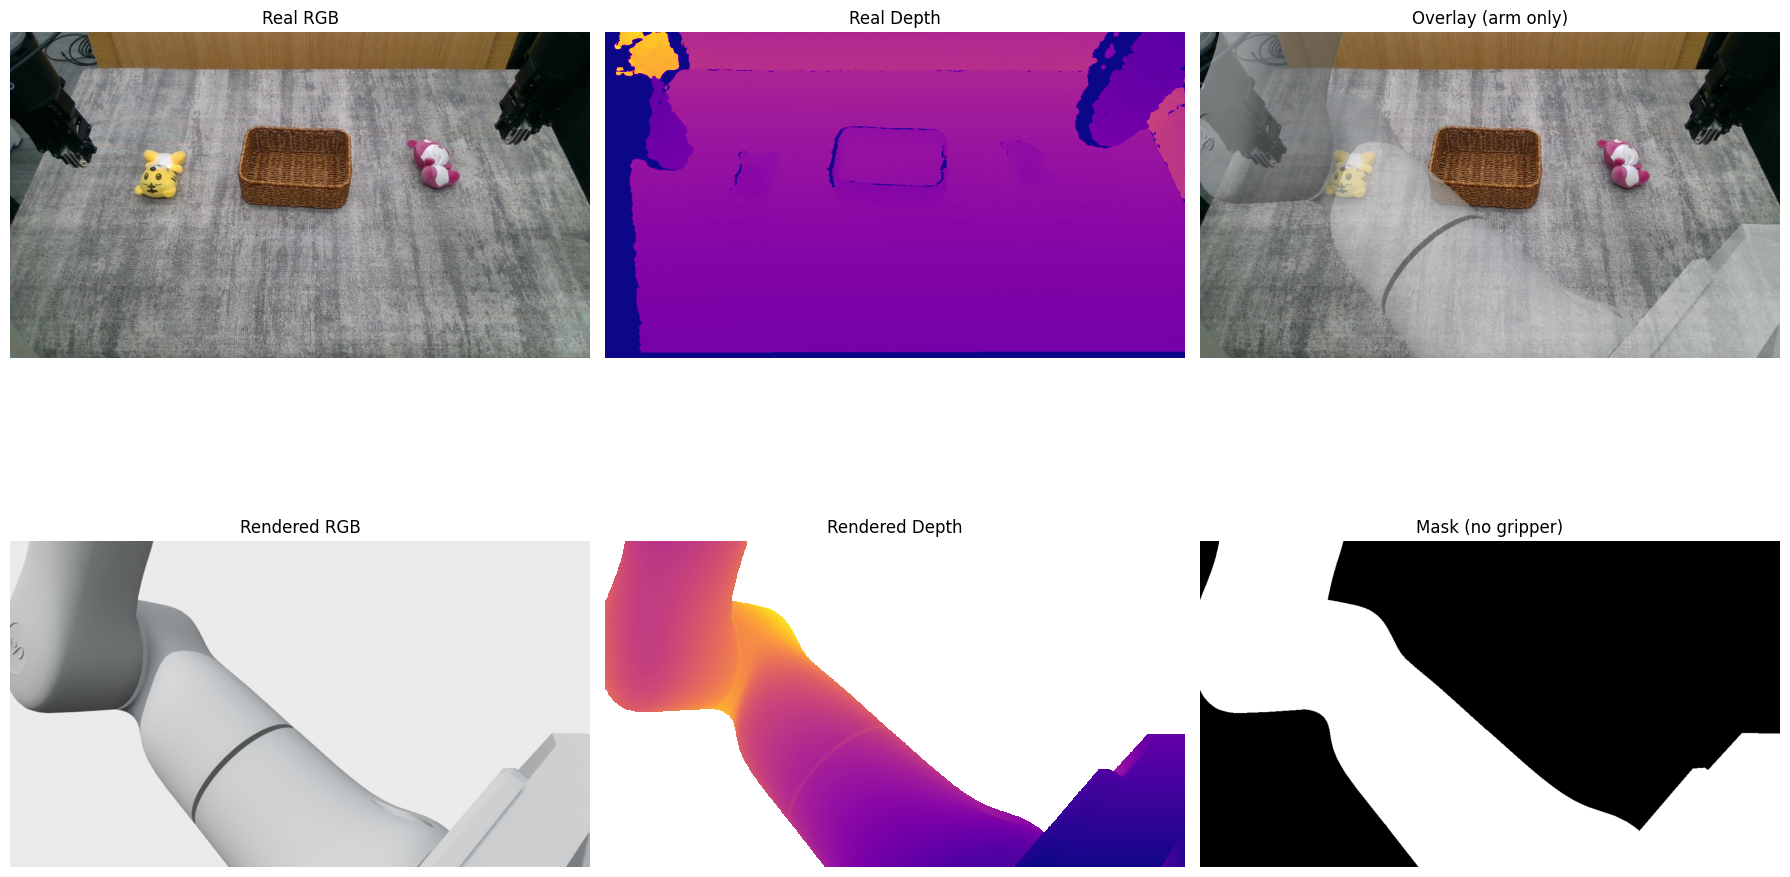

/tmp/ipykernel_1386216/1129546626.py:174: RuntimeWarning: invalid value encountered in cast
  cv2.imwrite(os.path.join(output_dir, "rendered_depth.png"), (rendered_depth * 1000).astype(np.uint16))



结果已保存到: /data/haoxiang/data/task0012_260321/task0012_toys_basket_converted/train/scene_0001/rendered_output
渲染图像形状: (720, 1280, 3)
深度范围: [0.223, inf] 米
掩码覆盖像素: 369221 / 921600


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import sys
from omegaconf import OmegaConf

workspace_root = "/home/haoxiang/rise2_mask_aware"
airexo_repo_root = os.path.join(workspace_root, "airexo")

for p in [workspace_root, airexo_repo_root]:
    if p not in sys.path:
        sys.path.insert(0, p)

for _m in [m for m in list(sys.modules.keys()) if m == "airexo" or m.startswith("airexo.")]:
    del sys.modules[_m]

from airexo.calibration.calib_info import CalibrationInfo
from airexo.helpers.constants import ROBOT_LEFT_CAM_TO_TCP, ROBOT_RIGHT_CAM_TO_TCP
from airexo.helpers.rotation import xyz_rot_to_mat
# ArmOnlyRobotRenderer 继承自 airexo RobotRenderer，渲染时过滤掉 gripper link，
# 使 render_mask() 只覆盖机械臂连杆（link1..7），不含夹爪。
from mask.renderer import ArmOnlyRobotRenderer

# ========== 1. 读取关节数据（直接从 lowdim.h5 读取） ==========
scene_path = "/data/haoxiang/data/task0012_260321/task0012_toys_basket_converted/train/scene_0001"
H5_PATH = os.path.join(scene_path, "lowdim", "lowdim.h5")

with h5py.File(H5_PATH, "r") as f:
    # 左右映射：
    # left  <- *_062703
    # right <- *_062046
    left_joint_core = np.asarray(f["joint_position_rad_062703"][0], dtype=np.float32)
    right_joint_core = np.asarray(f["joint_position_rad_062046"][0], dtype=np.float32)

    # gripper 这里先取 ee_state 作为单标量占位
    left_gripper = float(np.asarray(f["ee_state_062703"][0]).reshape(-1)[0])
    right_gripper = float(np.asarray(f["ee_state_062046"][0]).reshape(-1)[0])

left_joint = np.concatenate([left_joint_core, [left_gripper]], axis=0)
right_joint = np.concatenate([right_joint_core, [right_gripper]], axis=0)

print("H5_PATH:", H5_PATH)
print("left_joint:", left_joint.shape, left_joint)
print("right_joint:", right_joint.shape, right_joint)

# ========== 2. 加载标定数据 ==========
calib_path = "/data/haoxiang/data/task0012_260321/calib"
calib_info = CalibrationInfo(
    calib_path=calib_path,
    calib_timestamp=1234567
)

camera_serial = list(calib_info.camera_serials_global)[0]
print(f"Using camera: {camera_serial}")

cam_to_base = calib_info.get_camera_to_base(camera_serial)
intrinsic = calib_info.get_intrinsic(camera_serial)

# ========== 2.1 打印关键调试矩阵（重点排查合成逻辑） ==========
print("\n" + "=" * 80)
print("[Calibration Debug]")
print("=" * 80)
print("camera_serial:", camera_serial)
print("camera_serial_inhand_left:", calib_info.camera_serial_inhand_left)
print("camera_serial_inhand_right:", calib_info.camera_serial_inhand_right)

print("\n[cam_to_base]")
print(cam_to_base)

print("\n[intrinsic]")
print(intrinsic)

print("\n[extrinsics global]")
print(calib_info.extrinsics[camera_serial])

print("\n[extrinsics inhand left]")
print(calib_info.extrinsics[calib_info.camera_serial_inhand_left])

print("\n[extrinsics inhand right]")
print(calib_info.extrinsics[calib_info.camera_serial_inhand_right])

print("\n[robot_left tcp_pose]")
print(calib_info.robot_left["tcp_pose"])

print("\n[robot_right tcp_pose]")
print(calib_info.robot_right["tcp_pose"])

left_tcp_mat = xyz_rot_to_mat(calib_info.robot_left["tcp_pose"], rotation_rep="quaternion")
right_tcp_mat = xyz_rot_to_mat(calib_info.robot_right["tcp_pose"], rotation_rep="quaternion")

left_cam_to_base_real = (
    calib_info.extrinsics[camera_serial]
    @ np.linalg.inv(calib_info.extrinsics[calib_info.camera_serial_inhand_left])
    @ ROBOT_LEFT_CAM_TO_TCP
    @ np.linalg.inv(left_tcp_mat)
)
right_cam_to_base_real = (
    calib_info.extrinsics[camera_serial]
    @ np.linalg.inv(calib_info.extrinsics[calib_info.camera_serial_inhand_right])
    @ ROBOT_RIGHT_CAM_TO_TCP
    @ np.linalg.inv(right_tcp_mat)
)

print("\n[left_cam_to_base_real]")
print(left_cam_to_base_real)

print("\n[right_cam_to_base_real]")
print(right_cam_to_base_real)

print("=" * 80 + "\n")

# ========== 3. 加载配置 ==========
left_cfg  = OmegaConf.load(os.path.join(workspace_root, "airexo/airexo/configs/joint/left/robot.yaml"))
right_cfg = OmegaConf.load(os.path.join(workspace_root, "airexo/airexo/configs/joint/right/robot.yaml"))

# ========== 4. 初始化 Renderer（arm only） ==========
renderer = ArmOnlyRobotRenderer(
    left_joint_cfgs  = left_cfg,
    right_joint_cfgs = right_cfg,
    cam_to_base      = cam_to_base,
    intrinsic        = intrinsic,
    urdf_file        = os.path.join(workspace_root, "airexo/airexo/urdf_models/robot/robot_inhand.urdf"),
    width=1280,
    height=720,
    near_plane=0.01,
    far_plane=100.0
)

# ========== 5. 更新关节并渲染 ==========
renderer.update_joints(left_joint, right_joint)

rendered_rgb   = renderer.render_image()
rendered_depth = renderer.render_depth()
rendered_mask  = renderer.render_mask(depth=rendered_depth)

# ========== 6. 读取真实相机图像 ==========
cam_path = os.path.join(scene_path, "cam_104122060902")
rgb_path = os.path.join(cam_path, "color", "1774059832169.png")
depth_path = os.path.join(cam_path, "depth", "1774059832169.png")

real_rgb   = cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
real_depth = cv2.imread(depth_path, cv2.IMREAD_UNCHANGED).astype(np.float32) / 1000.0

# ========== 7. 叠加显示（机械臂覆盖在真实图像上） ==========
alpha = 0.6
overlay_rgb = real_rgb.copy()
mask_bool = rendered_mask > 0
overlay_rgb[mask_bool] = (
    rendered_rgb[mask_bool] * alpha +
    real_rgb[mask_bool] * (1 - alpha)
).astype(np.uint8)

# ========== 8. 可视化 ==========
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

axes[0, 0].imshow(real_rgb); axes[0, 0].set_title("Real RGB"); axes[0, 0].axis('off')
axes[0, 1].imshow(real_depth, cmap='plasma'); axes[0, 1].set_title("Real Depth"); axes[0, 1].axis('off')
axes[0, 2].imshow(overlay_rgb); axes[0, 2].set_title("Overlay (arm only)"); axes[0, 2].axis('off')

axes[1, 0].imshow(rendered_rgb); axes[1, 0].set_title("Rendered RGB"); axes[1, 0].axis('off')
axes[1, 1].imshow(rendered_depth, cmap='plasma'); axes[1, 1].set_title("Rendered Depth"); axes[1, 1].axis('off')
axes[1, 2].imshow(rendered_mask, cmap='gray'); axes[1, 2].set_title("Mask (no gripper)"); axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# ========== 9. 保存结果 ==========
output_dir = os.path.join(scene_path, "rendered_output")
os.makedirs(output_dir, exist_ok=True)

cv2.imwrite(os.path.join(output_dir, "rendered_rgb.png"), cv2.cvtColor(rendered_rgb, cv2.COLOR_RGB2BGR))
cv2.imwrite(os.path.join(output_dir, "rendered_depth.png"), (rendered_depth * 1000).astype(np.uint16))
cv2.imwrite(os.path.join(output_dir, "rendered_mask.png"), rendered_mask)
cv2.imwrite(os.path.join(output_dir, "overlay.png"), cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR))

print(f"\n结果已保存到: {output_dir}")
print(f"渲染图像形状: {rendered_rgb.shape}")
print(f"深度范围: [{rendered_depth.min():.3f}, {rendered_depth.max():.3f}] 米")
print(f"掩码覆盖像素: {(rendered_mask > 0).sum()} / {rendered_mask.size}")
